In [ ]:
%load_ext autoreload
%autoreload 2

import importlib
import sys
import os
import matplotlib.pyplot as plt
import sigpy.plot as pl
import sigpy as sp
import numpy as np
import glob

from radial_reader import RadialArchive
from bssfp_reader import bSSFPArchive
from split_xk_bpt import SplitXkBPT
from process_bpt import ProcessBPT, plot_bpts

%matplotlib inline
plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 20,               # Increase title font size
    'axes.labelsize': 18,               # Increase axis label font size
    'xtick.labelsize': 16,              # Increase x-tick label size
    'ytick.labelsize': 16,              # Increase y-tick label size
    "text.usetex": False,                # Enable LaTeX 
    'legend.fontsize': 12,
    'font.family': 'Avenir' # Avenir font
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We will load raw k-space from the largest ScanArchive in your chosen series. Then we will extract the BPT signals, and low-pass filter k-space to get BPT-free k-space (removing the zipper artifact from your images).

You can access the following variables (and more!):
- bssfp.xk_time: time-ordered k-space (Ncoils, Npe * Nslice, Nro)
- bssfp.xk_recon: trajectory-ordered k-space, to get images from (Ncoils, Nro, Npe, Nslice)

- split_xk_bpt.bpts: raw BPT signal(s) (1, Nsp, Nc)
- split_xk_bpt.xk_cleaned: BPT-free, coil-compressed k-space (Ncoils_comp, Nsp, Nr)

- process_bpt.bpts_lpf: filtered BPT signal(s) (Nsp, num_bpts * Nc) 
    - Can be unflattened with `_unflatten_bpts()`
    - Might need to use `force_reload=True` in `process_bpt.run()` to access this variable (it isn't cached).
- process_bpt.bpts_proc: processed BPT signals' principal components (Nsp, nrank)

In [48]:
# Path to Radial ScanArchive folder
inp_dir = "/mikLKS/rinbha/helping_people/ecg_pt/ecg_pt_052926/Exam54588/Series4"

# # Get k-space and metadata
# radial = RadialArchive(inpdir)
# radial.get_ksp(force_reload=False)

# Get k-space and metadata
bssfp = bSSFPArchive(inp_dir)
bssfp.get_ksp(force_reload=True)

# Get BPT and BPT-free k-space
split_xk_bpt = SplitXkBPT(inp_dir=inp_dir, verbose=True)
split_xk_bpt.run(force_reload=True)

# Get processed BPT signals
process_bpt = ProcessBPT(inp_dir=inp_dir, verbose=True, nrank=6)
process_bpt.lpf_cutoff_hz = 10 # LPF cutoff for PT signal (Hz)
process_bpt.run(force_reload=True) # can set to false

INFO: Cached data not found / used — extracting k-space.


INFO: Cached metadata not found / used — extracting.
INFO: Saving bSSFP Scan Archive metadata to metadata_dict.pkl.


Extracting k-space:   0%|          | 0/7681 [00:00<?, ?it/s]

INFO: Saving time-ordered k-space to xk.npy and trajectory-ordered k-space to xk_recon.npy.
INFO: Cleaned k-space and raw BPT/PT signals not found. Extracting...
INFO: Getting raw time-ordered k-space.
INFO: Getting hybrid raw k-space.
INFO: Getting coarse peaks.
INFO: Getting strongest tone.
INFO: Getting offsets.
100%|██████████| 7680/7680 [00:04<00:00, 1847.27it/s]
INFO: Aligning k-space.
INFO: Extracting BPT/PTs.
INFO: Cleaning k-space, still aligned.
INFO: Unaligning cleaned k-space.
INFO: Coil compressing k-space with PCA.
INFO: Saving cleaned k-space to /mikLKS/rinbha/helping_people/ecg_pt/ecg_pt_052926/Exam54588/Series4/xk_cleaned_comp.npy and raw BPT/PT signals to /mikLKS/rinbha/helping_people/ecg_pt/ecg_pt_052926/Exam54588/Series4/bpts.npy.
INFO: Processed BPT/PTs not found. Extracting them...
INFO: TR found from metadata: 4.30 ms
INFO: Loading raw BPT/PTs...
INFO: Applying median filter to BPT/PTs...
INFO: Applying low-pass filter to BPT/PTs...
INFO: Normalizing BPT/PTs...
I

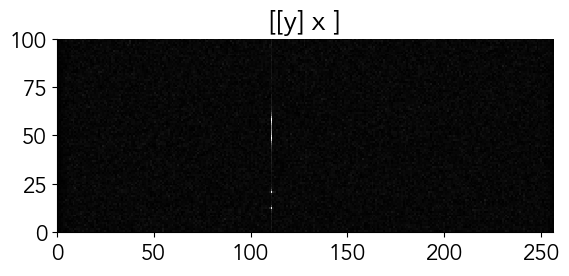

In [ ]:
pl.ImagePlot(sp.ifft(bssfp.xk_time[15,:100,:],axes=(-1,)))

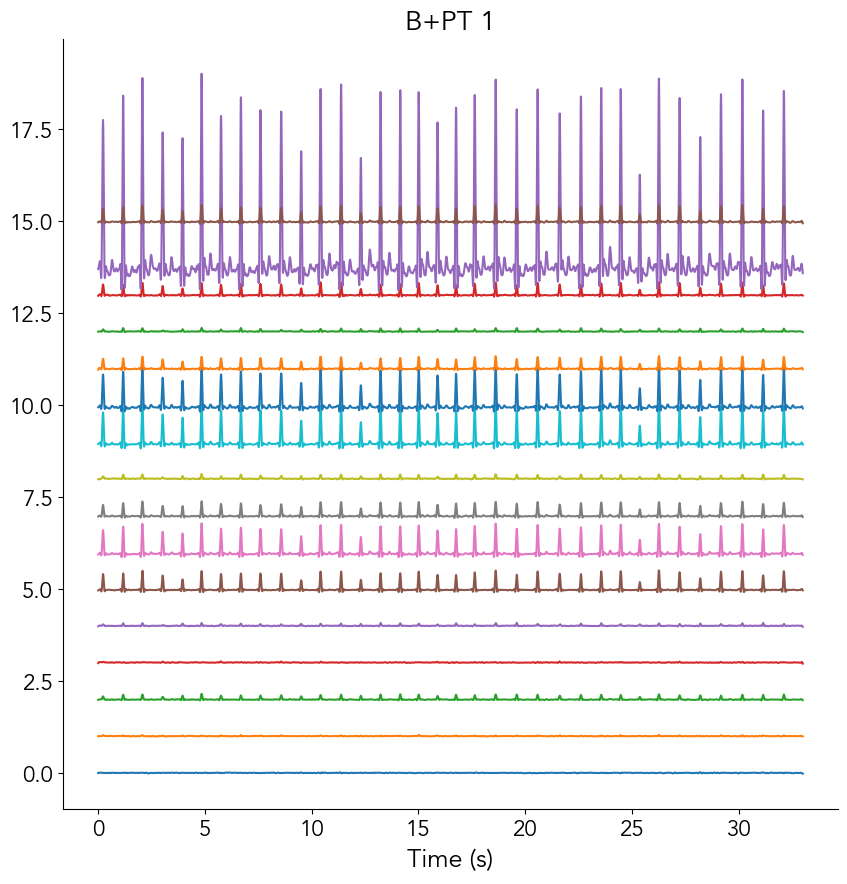

In [54]:
plot_bpts(process_bpt.bpts_lpf, process_bpt.tr, rel_shift=0.2)